# Task 2 - Support Vector Machine

Dans ce notebook, nous allons implémenter un modèle de machines à vecteurs de support (SVM), un algorithme puissant en machine learning supervisé pour la classification et la régression, basé sur la recherche d'hyperplans optimaux.

## 1. Importation des bibliothèques nécessaires

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_breast_cancer
import warnings
warnings.filterwarnings('ignore')

# Configuration de l'affichage
%matplotlib inline

## 2. Chargement et exploration des données

Pour cette démonstration, nous utiliserons le jeu de données du cancer du sein de Wisconsin, qui est un problème de classification binaire classique.

In [2]:
# Chargement des données du cancer du sein de Wisconsin
breast_cancer = load_breast_cancer()

# Création d'un DataFrame pandas
df = pd.DataFrame(data=breast_cancer.data, columns=breast_cancer.feature_names)
df['target'] = breast_cancer.target

df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [3]:
# Exploration des données
print("Shape of dataset:", df.shape)
print("\nInfo of dataset:")
df.info()

Shape of dataset: (569, 31)

Info of dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-n

In [4]:
# Statistiques descriptives
df.describe()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.627417
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,1.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000


Variable cible: target

Distribution des classes:
target
1    357
0    212
Name: count, dtype: int64


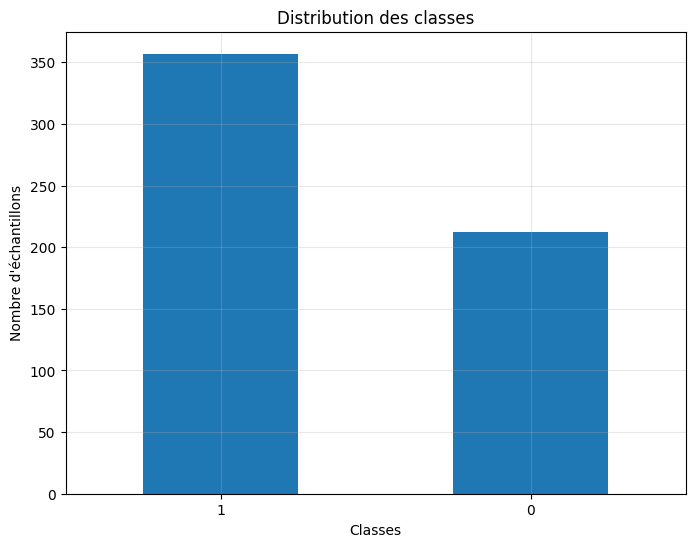

In [5]:
# Vérification de la distribution des classes (variable cible)
target_column = df.columns[-1]
print(f"Variable cible: {target_column}")
print("\nDistribution des classes:")
print(df[target_column].value_counts())

# Visualisation de la distribution des classes
plt.figure(figsize=(8, 6))
df[target_column].value_counts().plot(kind='bar')
plt.title('Distribution des classes')
plt.xlabel('Classes')
plt.ylabel('Nombre d\'échantillons')
plt.xticks(rotation=0)
plt.grid(True, alpha=0.3)
plt.show()

## 3. Prétraitement des données

Séparation des caractéristiques (features) et de la variable cible, puis normalisation des données (essentielle pour les SVM).

In [6]:
# Séparation des caractéristiques (features) et de la variable cible
X = df.iloc[:, :-1]  # Toutes les colonnes sauf la dernière
y = df.iloc[:, -1]   # Dernière colonne (variable cible)

print(f"Dimensions des caractéristiques: {X.shape}")
print(f"Dimensions de la variable cible: {y.shape}")

Dimensions des caractéristiques: (569, 30)
Dimensions de la variable cible: (569,)


In [7]:
# Normalisation des données (très importante pour les SVM)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convertir en DataFrame pour faciliter la manipulation
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)
print("Données après normalisation:")
X_scaled.head()

Données après normalisation:


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,1.097064,-2.073335,1.269934,0.984375,1.568466,3.283515,2.652874,2.532475,2.217515,2.255747,...,1.886690,-1.359293,2.303601,2.001237,1.307686,2.616665,2.109526,2.296076,2.750622,1.937015
1,1.829821,-0.353632,1.685955,1.908708,-0.826962,-0.487072,-0.023846,0.548144,0.001392,-0.868652,...,1.805927,-0.369203,1.535126,1.890489,-0.375612,-0.430444,-0.146749,1.087084,-0.243890,0.281190
2,1.579888,0.456187,1.566503,1.558884,0.942210,1.052926,1.363478,2.037231,0.939685,-0.398008,...,1.511870,-0.023974,1.347475,1.456285,0.527407,1.082932,0.854974,1.955000,1.152255,0.201391
3,-0.768909,0.253732,-0.592687,-0.764464,3.283553,3.402909,1.915897,1.451707,2.867383,4.910919,...,-0.281464,0.133984,-0.249939,-0.550021,3.394275,3.893397,1.989588,2.175786,6.046041,4.935010
4,1.750297,-1.151816,1.776573,1.826229,0.280372,0.539340,1.371011,1.428493,-0.009560,-0.562450,...,1.298575,-1.466770,1.338539,1.220724,0.220556,-0.313395,0.613179,0.729259,-0.868353,-0.397100


## 4. Division des données

Division des données en ensembles d'entraînement et de test.

In [8]:
# Division des données en ensembles d'entraînement et de test
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

print(f"Taille de l'ensemble d'entraînement: {X_train.shape}")
print(f"Taille de l'ensemble de test: {X_test.shape}")

Taille de l'ensemble d'entraînement: (455, 30)
Taille de l'ensemble de test: (114, 30)


## 5. Entraînement du modèle SVM avec noyau linéaire

Création et entraînement du modèle SVM avec un noyau linéaire.

In [9]:
# Création et entraînement du modèle SVM avec noyau linéaire
svm_linear = SVC(kernel='linear', random_state=42, probability=True)
svm_linear.fit(X_train, y_train)

SVC(kernel='linear', probability=True, random_state=42)

## 6. Prédiction et évaluation du modèle SVM linéaire

Prédiction sur l'ensemble de test et évaluation des performances du modèle.

In [10]:
# Prédiction sur l'ensemble de test
y_pred_linear = svm_linear.predict(X_test)
y_pred_proba_linear = svm_linear.predict_proba(X_test)[:, 1]  # Probabilités pour la classe positive

# Affichage des premières prédictions
results_df = pd.DataFrame({'Valeurs réelles': y_test, 'Prédictions': y_pred_linear, 'Probabilités': y_pred_proba_linear})
print("Comparaison des valeurs réelles et prédites (SVM linéaire):")
print(results_df.head(10))

Comparaison des valeurs réelles et prédites (SVM linéaire):
     Valeurs réelles  Prédictions  Probabilités
256                0            0  5.219326e-07
428                1            1  1.000000e+00
501                0            0  1.221885e-02
363                1            0  5.490299e-01
564                0            0  1.000000e-07
464                1            1  9.823127e-01
358                1            1  1.000000e+00
343                0            0  4.270804e-06
516                0            0  1.952298e-04
567                0            0  1.000000e-07


In [11]:
# Évaluation du modèle
accuracy_linear = accuracy_score(y_test, y_pred_linear)
print(f"Précision du modèle SVM linéaire: {accuracy_linear:.4f}")

# Rapport de classification détaillé
print("\nRapport de classification (SVM linéaire):")
print(classification_report(y_test, y_pred_linear))

Précision du modèle SVM linéaire: 0.9737

Rapport de classification (SVM linéaire):
              precision    recall  f1-score   support

           0       0.95      0.98      0.96        42
           1       0.99      0.97      0.98        72

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



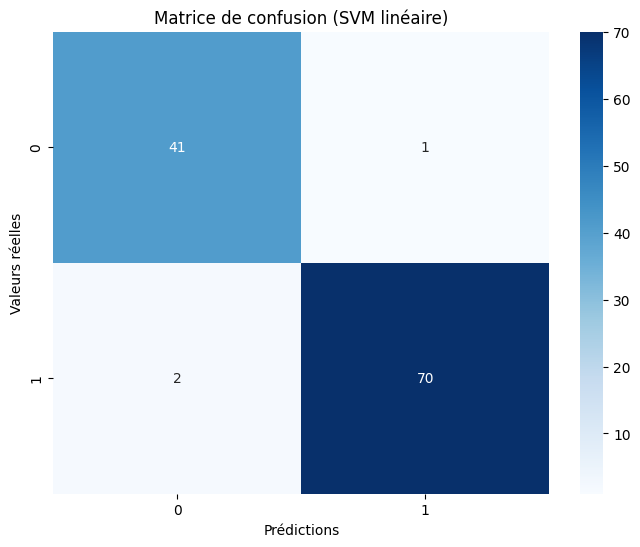

In [12]:
# Matrice de confusion
cm_linear = confusion_matrix(y_test, y_pred_linear)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_linear, annot=True, fmt='d', cmap='Blues')
plt.title('Matrice de confusion (SVM linéaire)')
plt.xlabel('Prédictions')
plt.ylabel('Valeurs réelles')
plt.show()

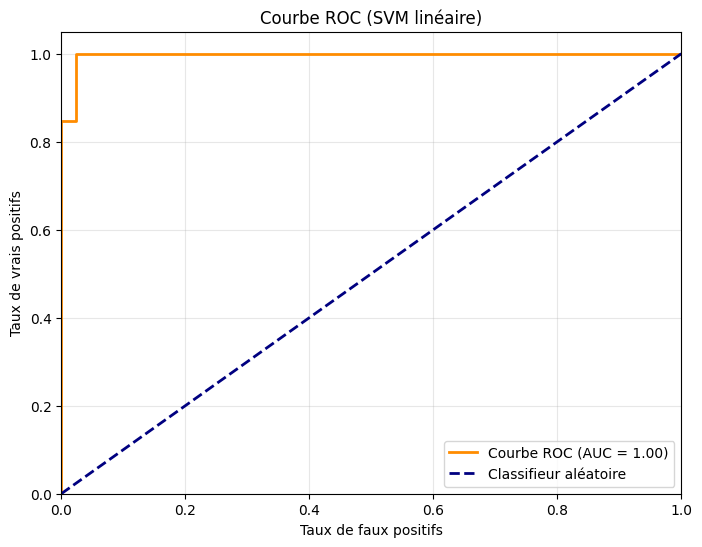

Aire sous la courbe ROC (AUC) - SVM linéaire: 0.9964


In [13]:
# Courbe ROC et AUC
fpr_linear, tpr_linear, thresholds_linear = roc_curve(y_test, y_pred_proba_linear)
roc_auc_linear = auc(fpr_linear, tpr_linear)

plt.figure(figsize=(8, 6))
plt.plot(fpr_linear, tpr_linear, color='darkorange', lw=2, label=f'Courbe ROC (AUC = {roc_auc_linear:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Classifieur aléatoire')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taux de faux positifs')
plt.ylabel('Taux de vrais positifs')
plt.title('Courbe ROC (SVM linéaire)')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()

print(f"Aire sous la courbe ROC (AUC) - SVM linéaire: {roc_auc_linear:.4f}")

## 7. Entraînement du modèle SVM avec noyau RBF

Création et entraînement du modèle SVM avec un noyau RBF (radial basis function).

In [14]:
# Création et entraînement du modèle SVM avec noyau RBF
svm_rbf = SVC(kernel='rbf', random_state=42, probability=True)
svm_rbf.fit(X_train, y_train)

SVC(probability=True, random_state=42)

## 8. Prédiction et évaluation du modèle SVM RBF

Prédiction sur l'ensemble de test et évaluation des performances du modèle.

In [15]:
# Prédiction sur l'ensemble de test
y_pred_rbf = svm_rbf.predict(X_test)
y_pred_proba_rbf = svm_rbf.predict_proba(X_test)[:, 1]  # Probabilités pour la classe positive

# Affichage des premières prédictions
results_df = pd.DataFrame({'Valeurs réelles': y_test, 'Prédictions': y_pred_rbf, 'Probabilités': y_pred_proba_rbf})
print("Comparaison des valeurs réelles et prédites (SVM RBF):")
print(results_df.head(10))

Comparaison des valeurs réelles et prédites (SVM RBF):
     Valeurs réelles  Prédictions  Probabilités
256                0            0      0.001172
428                1            1      0.999999
501                0            0      0.008597
363                1            1      0.583364
564                0            0      0.005351
464                1            1      0.991023
358                1            1      0.999995
343                0            0      0.000523
516                0            0      0.000090
567                0            0      0.021369


In [16]:
# Évaluation du modèle
accuracy_rbf = accuracy_score(y_test, y_pred_rbf)
print(f"Précision du modèle SVM RBF: {accuracy_rbf:.4f}")

# Rapport de classification détaillé
print("\nRapport de classification (SVM RBF):")
print(classification_report(y_test, y_pred_rbf))

Précision du modèle SVM RBF: 0.9825

Rapport de classification (SVM RBF):
              precision    recall  f1-score   support

           0       0.98      0.98      0.98        42
           1       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



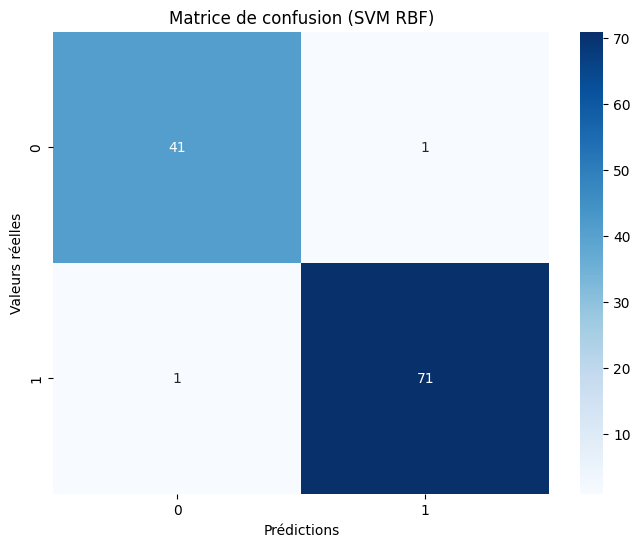

In [17]:
# Matrice de confusion
cm_rbf = confusion_matrix(y_test, y_pred_rbf)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_rbf, annot=True, fmt='d', cmap='Blues')
plt.title('Matrice de confusion (SVM RBF)')
plt.xlabel('Prédictions')
plt.ylabel('Valeurs réelles')
plt.show()

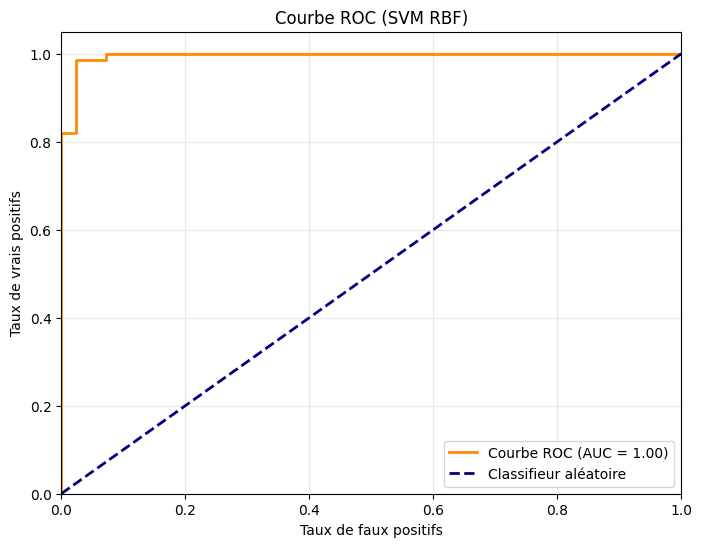

Aire sous la courbe ROC (AUC) - SVM RBF: 0.9950


In [18]:
# Courbe ROC et AUC
fpr_rbf, tpr_rbf, thresholds_rbf = roc_curve(y_test, y_pred_proba_rbf)
roc_auc_rbf = auc(fpr_rbf, tpr_rbf)

plt.figure(figsize=(8, 6))
plt.plot(fpr_rbf, tpr_rbf, color='darkorange', lw=2, label=f'Courbe ROC (AUC = {roc_auc_rbf:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Classifieur aléatoire')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taux de faux positifs')
plt.ylabel('Taux de vrais positifs')
plt.title('Courbe ROC (SVM RBF)')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()

print(f"Aire sous la courbe ROC (AUC) - SVM RBF: {roc_auc_rbf:.4f}")

## 9. Optimisation des hyperparamètres pour SVM RBF

Utilisation de GridSearchCV pour trouver les meilleurs hyperparamètres pour le noyau RBF.

In [19]:
# Définition de la grille de paramètres
param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 'auto', 0.001, 0.01, 0.1, 1]
}

# Recherche des meilleurs paramètres
grid_search = GridSearchCV(
    estimator=SVC(kernel='rbf', random_state=42, probability=True),
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Meilleurs paramètres trouvés pour SVM RBF:")
print(grid_search.best_params_)
print(f"\nMeilleur score de validation croisée: {grid_search.best_score_:.4f}")

Meilleurs paramètres trouvés pour SVM RBF:
{'C': 10, 'gamma': 0.01}

Meilleur score de validation croisée: 0.9802


In [20]:
# Entraînement du modèle avec les meilleurs paramètres
best_svm = grid_search.best_estimator_
y_pred_best = best_svm.predict(X_test)
y_pred_proba_best = best_svm.predict_proba(X_test)[:, 1]

# Évaluation du modèle optimisé
accuracy_best = accuracy_score(y_test, y_pred_best)
print(f"Précision du modèle SVM RBF optimisé: {accuracy_best:.4f}")

print("\nRapport de classification du modèle SVM RBF optimisé:")
print(classification_report(y_test, y_pred_best))

Précision du modèle SVM RBF optimisé: 0.9825

Rapport de classification du modèle SVM RBF optimisé:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98        42
           1       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



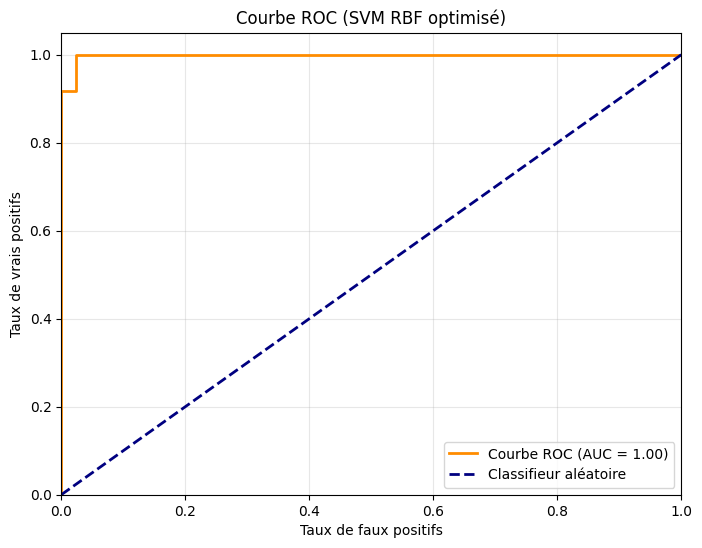

Aire sous la courbe ROC (AUC) - SVM RBF optimisé: 0.9980


In [21]:
# Courbe ROC et AUC du modèle optimisé
fpr_best, tpr_best, thresholds_best = roc_curve(y_test, y_pred_proba_best)
roc_auc_best = auc(fpr_best, tpr_best)

plt.figure(figsize=(8, 6))
plt.plot(fpr_best, tpr_best, color='darkorange', lw=2, label=f'Courbe ROC (AUC = {roc_auc_best:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Classifieur aléatoire')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taux de faux positifs')
plt.ylabel('Taux de vrais positifs')
plt.title('Courbe ROC (SVM RBF optimisé)')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()

print(f"Aire sous la courbe ROC (AUC) - SVM RBF optimisé: {roc_auc_best:.4f}")

## 10. Comparaison des différents noyaux

Comparaison des performances entre différents noyaux SVM.

In [22]:
# Test de différents noyaux
kernels = ['linear', 'poly', 'rbf', 'sigmoid']
svm_models = {}
accuracies = {}
roc_aucs = {}

for kernel in kernels:
    # Pour le noyau polynomial, utilisons un degré faible pour éviter le sur-apprentissage
    if kernel == 'poly':
        svm = SVC(kernel=kernel, degree=2, random_state=42, probability=True)
    else:
        svm = SVC(kernel=kernel, random_state=42, probability=True)

    svm.fit(X_train, y_train)
    y_pred = svm.predict(X_test)
    y_pred_proba = svm.predict_proba(X_test)[:, 1]

    svm_models[kernel] = svm
    accuracies[kernel] = accuracy_score(y_test, y_pred)

    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    roc_aucs[kernel] = auc(fpr, tpr)

# Affichage des résultats
print("Comparaison des noyaux SVM:")
print("-" * 40)
for kernel in kernels:
    print(f"{kernel.capitalize():10} | Précision: {accuracies[kernel]:.4f} | AUC: {roc_aucs[kernel]:.4f}")

Comparaison des noyaux SVM:
----------------------------------------
Linear     | Précision: 0.9737 | AUC: 0.9964
Poly       | Précision: 0.7982 | AUC: 0.8737
Rbf        | Précision: 0.9825 | AUC: 0.9950
Sigmoid    | Précision: 0.9211 | AUC: 0.9871


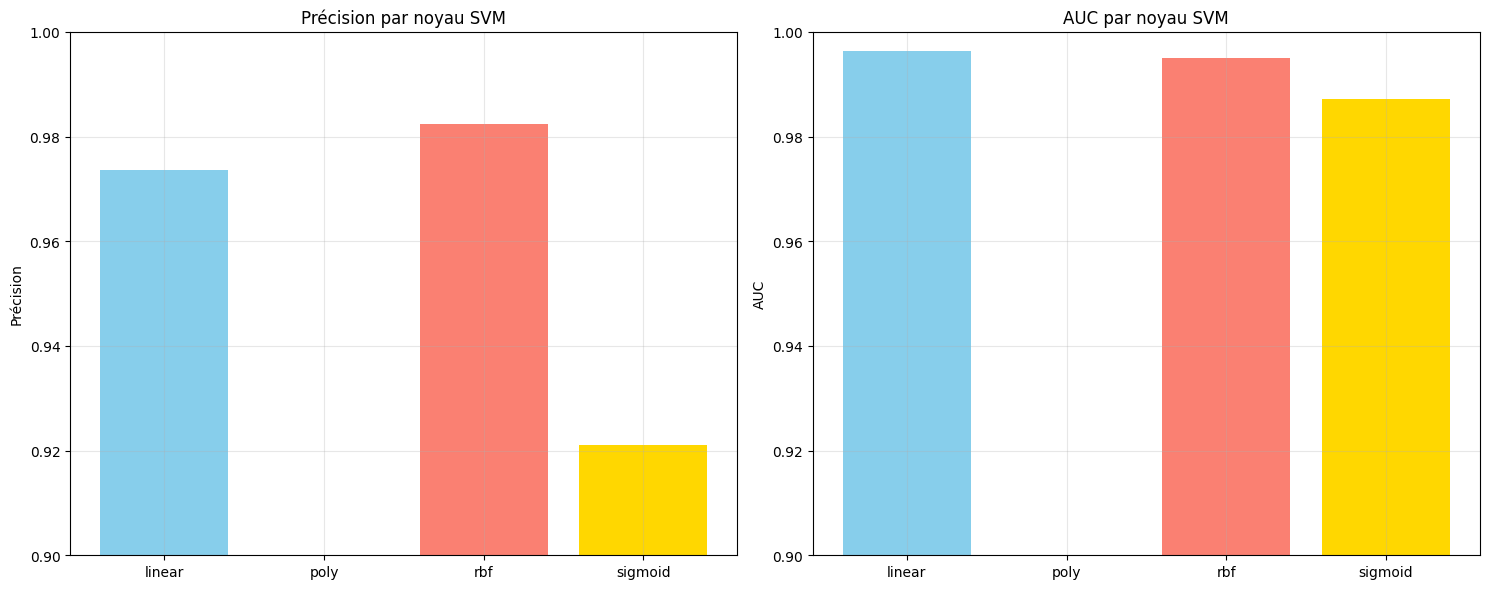

In [23]:
# Visualisation de la comparaison
fig, ax = plt.subplots(1, 2, figsize=(15, 6))

# Précision
ax[0].bar(accuracies.keys(), accuracies.values(), color=['skyblue', 'lightgreen', 'salmon', 'gold'])
ax[0].set_title('Précision par noyau SVM')
ax[0].set_ylabel('Précision')
ax[0].set_ylim([0.9, 1.0])
ax[0].grid(True, alpha=0.3)

# AUC
ax[1].bar(roc_aucs.keys(), roc_aucs.values(), color=['skyblue', 'lightgreen', 'salmon', 'gold'])
ax[1].set_title('AUC par noyau SVM')
ax[1].set_ylabel('AUC')
ax[1].set_ylim([0.9, 1.0])
ax[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Conclusion

Dans ce notebook, nous avons implémenté des modèles de machines à vecteurs de support :
- Chargement et exploration des données du cancer du sein
- Prétraitement des données avec normalisation (essentielle pour les SVM)
- Division des données en ensembles d'entraînement et de test
- Entraînement de modèles SVM avec différents noyaux (linéaire, RBF)
- Évaluation des modèles avec plusieurs métriques (précision, rappel, F1-score, AUC)
- Visualisation des résultats (matrices de confusion, courbes ROC)
- Optimisation des hyperparamètres avec GridSearchCV
- Comparaison des performances entre différents noyaux

Les SVM sont des algorithmes puissants qui fonctionnent particulièrement bien dans des espaces de grande dimension. La normalisation des données est cruciale pour leur bon fonctionnement. Le choix du noyau et le réglage des hyperparamètres (C, gamma) ont un impact majeur sur les performances du modèle.